# Лабораторна робота 10.3
## Тема: Перенесення навчання (Transfer Learning) та Fine Tuning для набору даних Коти-Собаки

**Завдання:**
1. Підготувати набір даних: 2000 train, 500 val, 500 test для кожного класу.
2. Використати VGG16 для Transfer Learning.
3. Застосувати Fine Tuning.
4. Порівняти результати.

In [17]:
!curl -L -o ./cats_dogs.zip https://www.kaggle.com/api/v1/datasets/download/bhavikjikadara/dog-and-cat-classification-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  775M  100  775M    0     0  88.3M      0  0:00:08  0:00:08 --:--:--  118M


In [18]:
!unzip cats_dogs.zip

Archive:  cats_dogs.zip
replace PetImages/Cat/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os
import random
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from shutil import copyfile
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import layers
from tensorflow.keras import Model

base_dir = "./PetImages"
if not os.path.exists(base_dir):
    os.mkdir(base_dir)

train_dir = os.path.join(base_dir, 'training')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'testing')

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
test_cats_dir = os.path.join(test_dir, 'cats')
test_dogs_dir = os.path.join(test_dir, 'dogs')

for directory in [train_dir, validation_dir, test_dir, train_cats_dir, train_dogs_dir, 
                  validation_cats_dir, validation_dogs_dir, test_cats_dir, test_dogs_dir]:
    if not os.path.exists(directory):
        os.makedirs(directory)

In [ ]:
def split_data(SOURCE, TRAINING, VALIDATION, TESTING, TRAIN_SIZE, VAL_SIZE, TEST_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        file = os.path.join(SOURCE, filename)
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    if len(files) < (TRAIN_SIZE + VAL_SIZE + TEST_SIZE):
        print(f"Not enough images in {SOURCE} to split. Found {len(files)}, required {TRAIN_SIZE + VAL_SIZE + TEST_SIZE}")
        return

    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:TRAIN_SIZE]
    validation_set = shuffled_set[TRAIN_SIZE:(TRAIN_SIZE + VAL_SIZE)]
    test_set = shuffled_set[(TRAIN_SIZE + VAL_SIZE):(TRAIN_SIZE + VAL_SIZE + TEST_SIZE)]
    
    print(f"Splitting {SOURCE}")
    print(f"Training: {len(training_set)}")
    print(f"Validation: {len(validation_set)}")
    print(f"Testing: {len(test_set)}")

    for directory in [TRAINING, VALIDATION, TESTING]:
        for f in os.listdir(directory):
            os.remove(os.path.join(directory, f))

    for filename in training_set:
        this_file = os.path.join(SOURCE, filename)
        destination = os.path.join(TRAINING, filename)
        copyfile(this_file, destination)

    for filename in validation_set:
        this_file = os.path.join(SOURCE, filename)
        destination = os.path.join(VALIDATION, filename)
        copyfile(this_file, destination)
        
    for filename in test_set:
        this_file = os.path.join(SOURCE, filename)
        destination = os.path.join(TESTING, filename)
        copyfile(this_file, destination)
        
    # Verification
    print(f"Verifying split for {SOURCE}...")
    print(f"Training dir has {len(os.listdir(TRAINING))} images")
    print(f"Validation dir has {len(os.listdir(VALIDATION))} images")
    print(f"Testing dir has {len(os.listdir(TESTING))} images")
    print("-" * 30)

CAT_SOURCE_DIR = "./PetImages/Cat/"
DOG_SOURCE_DIR = "./PetImages/Dog/"

split_data(CAT_SOURCE_DIR, train_cats_dir, validation_cats_dir, test_cats_dir, 2000, 500, 500)
split_data(DOG_SOURCE_DIR, train_dogs_dir, validation_dogs_dir, test_dogs_dir, 2000, 500, 500)

Splitting ./PetImages/Cat/
Training: 2000
Validation: 500
Testing: 500
Verifying split for ./PetImages/Cat/...
Training dir has 2000 images
Validation dir has 500 images
Testing dir has 500 images
------------------------------
Splitting ./PetImages/Dog/
Training: 2000
Validation: 500
Testing: 500
Verifying split for ./PetImages/Dog/...
Training dir has 2000 images
Validation dir has 500 images
Testing dir has 500 images
------------------------------


## Transfer Learning з VGG16

In [19]:
pre_trained_model = VGG16(
    input_shape=(150, 150, 3), include_top=False, weights="imagenet"
)

for layer in pre_trained_model.layers:
    layer.trainable = False

# pre_trained_model.summary()

last_layer = pre_trained_model.get_layer("block5_pool")
last_output = last_layer.output

x = layers.Flatten()(last_output)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(1, activation="sigmoid")(x)

model = Model(pre_trained_model.input, x)

model.compile(
    optimizer=RMSprop(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir, batch_size=20, class_mode="binary", target_size=(150, 150)
)

validation_generator = test_datagen.flow_from_directory(
    validation_dir, batch_size=20, class_mode="binary", target_size=(150, 150)
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    steps_per_epoch=100,
    epochs=10,
    validation_steps=25,
)

Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 0.6535 - loss: 0.6946 - val_accuracy: 0.8320 - val_loss: 0.3880
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 164ms/step - accuracy: 0.7714 - loss: 0.4578 - val_accuracy: 0.8840 - val_loss: 0.2593
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 160ms/step - accuracy: 0.8214 - loss: 0.3951 - val_accuracy: 0.8940 - val_loss: 0.2725
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 159ms/step - accuracy: 0.8080 - loss: 0.4352 - val_accuracy: 0.9040 - val_loss: 0.2485
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step - accuracy: 0.8249 - loss: 0.3854 - val_accuracy: 0.9020 - val_loss: 0.2502
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 160ms/step - accuracy: 0.8595 - loss: 0.3411 - val_accuracy: 0.9100 - val_loss: 0.2258
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step - accuracy: 0.8308 - loss: 0.3660 - val_accuracy: 0.9040 - val_loss: 0.2450

In [29]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import os
from tensorflow.keras.applications.vgg16 import (
    preprocess_input as vgg16_preprocess_input,
)

print("TensorFlow version:", tf.__version__)

MODEL_CONFIG = {
    "target_size": (150, 150),
    "preprocess_func": vgg16_preprocess_input,
}

directories_to_scan = [(test_cats_dir, "CAT"), (test_dogs_dir, "DOG")]

results = []
total_images = 0

print("Starting predictions...")

for folder_path, actual_label in directories_to_scan:
    if not os.path.exists(folder_path):
        print(f"\nError: Folder not found: {folder_path}")
        continue

    filenames = [
        f
        for f in os.listdir(folder_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]
    total_images += len(filenames)

    print(f"\nProcessing {len(filenames)} images from: {folder_path}", end="")

    for filename in filenames:
        img_path = os.path.join(folder_path, filename)

        try:
            img = image.load_img(img_path, target_size=MODEL_CONFIG["target_size"])
            img_array = image.img_to_array(img)
            img_array_expanded = np.expand_dims(img_array, axis=0)
            processed_img = MODEL_CONFIG["preprocess_func"](img_array_expanded)

            prediction = model.predict(processed_img, verbose=0)
            score = prediction[0][0]

            if score < 0.5:
                result_label = "CAT"
                confidence = (1 - score) * 100
            else:
                result_label = "DOG"
                confidence = score * 100

            results.append(
                {
                    "file": filename,
                    "label": result_label,
                    "actual": actual_label,
                    "score": score,
                    "conf": confidence,
                }
            )

        except Exception as e:
            print(f"\nError processing {filename}: {e}")


TensorFlow version: 2.19.0
Starting predictions...

Processing 500 images from: ./PetImages/testing/cats
Processing 500 images from: ./PetImages/testing/dogs

In [33]:
print("\n\n" + "=" * 95)
print(" ANALYSIS OF ERRORS & UNCERTAINTY")
print(" Only showing: Wrong predictions OR Confidence < 99.99%")
print("-" * 95)
print(f"{'FILENAME':<30} | {'PRED':<5} | {'ACTUAL':<6} | {'CONF':<8} | {'ISSUE TYPE'}")
print("-" * 95)

filtered_count = 0

for res in results:
    is_wrong = res["label"] != res["actual"]
    is_not_confident = res["conf"] < 99.99

    if is_wrong or is_not_confident:
        filtered_count += 1

        issues = []
        if is_wrong:
            issues.append("WRONG LABEL")
        if is_not_confident:
            issues.append("LOW CONFIDENCE")
        issue_msg = " + ".join(issues)

        print(
            f"{res['file']:<30} | {res['label']:<5} | {res['actual']:<6} | {res['conf']:>6.2f}% | {issue_msg}"
        )

print("-" * 95)
print(f"Total images processed: {len(results)}")
print(f"Issues found: {filtered_count}")
accuracy = (
    ((len(results) - filtered_count) / len(results)) * 100 if len(results) > 0 else 0
)
real_accuracy = (
    sum(1 for r in results if r["label"] == r["actual"]) / len(results) * 100
    if len(results) > 0
    else 0
)
print(f"Real Model Accuracy: {real_accuracy:.2f}%")
print("=" * 95)




 ANALYSIS OF ERRORS & UNCERTAINTY
 Only showing: Wrong predictions OR Confidence < 99.99%
-----------------------------------------------------------------------------------------------
FILENAME                       | PRED  | ACTUAL | CONF     | ISSUE TYPE
-----------------------------------------------------------------------------------------------
166.jpg                        | DOG   | CAT    | 100.00% | WRONG LABEL
2995.jpg                       | DOG   | CAT    | 100.00% | WRONG LABEL
9745.jpg                       | DOG   | CAT    | 100.00% | WRONG LABEL
8719.jpg                       | DOG   | CAT    | 100.00% | WRONG LABEL
12152.jpg                      | DOG   | CAT    | 100.00% | WRONG LABEL
2410.jpg                       | DOG   | CAT    | 100.00% | WRONG LABEL
4868.jpg                       | DOG   | CAT    | 100.00% | WRONG LABEL
6904.jpg                       | DOG   | CAT    | 100.00% | WRONG LABEL
3009.jpg                       | DOG   | CAT    | 100.00% | WRONG LA

In [34]:
import ipywidgets as widgets
from IPython.display import display
import os

SAVE_DIR = "uploaded_files"
os.makedirs(SAVE_DIR, exist_ok=True)

uploader_multi = widgets.FileUpload(multiple=True, accept="")

display(uploader_multi)


FileUpload(value={}, description='Upload', multiple=True)

In [36]:
for file in uploader_multi.value.values():
    with open(os.path.join(SAVE_DIR, file["metadata"]["name"]), "wb") as fp:
        fp.write(file["content"])

In [37]:
!ls ./uploaded_files

cat.1.png  cat.3.png  cat.5.png  dog.2.png  dog.4.png  horse
cat.2.png  cat.4.png  dog.1.png  dog.3.png  dog.5.png  person


In [38]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
import os
import shutil


def predict_image(path, model):
    try:
        img = load_img(path, target_size=(150, 150))
        x = img_to_array(img)
        x /= 255
        x = np.expand_dims(x, axis=0)
        images = np.vstack([x])
        classes = model.predict(images, batch_size=10)
        return classes[0][0]
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return None


test_path = r"./uploaded_files"
fnames = {
    "horse": [f"cat.{i}.png" for i in range(1, 6)],
    "person": [f"dog.{i}.png" for i in range(1, 6)],
}

if os.path.exists(test_path):
    print(f"Found test_images directory at {test_path}")
    for subdir in ["horse", "person"]:
        subdir_path = os.path.join(test_path, subdir)
        os.makedirs(subdir_path, exist_ok=True)
        for fname in fnames[subdir]:
            shutil.copyfile(
                os.path.join(test_path, fname), os.path.join(subdir_path, fname)
            )

        print(f"\n--- Testing images in {subdir} ---")
        files = os.listdir(subdir_path)
        for fn in files:
            path = os.path.join(subdir_path, fn)
            val = predict_image(path, model)
            if val is not None:
                if val > 0.5:
                    print(f"{fn}: Predicted DOG ({val:.4f})")
                else:
                    print(f"{fn}: Predicted CAT ({val:.4f})")
else:
    print(
        f"Could not find test_images directory at {test_path}. Please check the path."
    )


Found test_images directory at ./uploaded_files

--- Testing images in horse ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
cat.3.png: Predicted DOG (0.6175)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
cat.5.png: Predicted CAT (0.1237)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
cat.1.png: Predicted CAT (0.0011)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
cat.4.png: Predicted CAT (0.4340)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
cat.2.png: Predicted CAT (0.0022)

--- Testing images in person ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
dog.1.png: Predicted DOG (0.9972)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
dog.2.png: Predicted DOG (0.8932)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
dog.5.png: Predicted DOG (0.9797)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
dog.4.png: Predicted CAT (0.0576)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
dog.3.png: Predicted DOG (0.5385)


## Fine Tuning для VGG16

In [27]:
from tensorflow.keras.optimizers import SGD

pre_trained_model.trainable = True
set_trainable = False
for layer in pre_trained_model.layers:
    if layer.name == "block5_conv1":
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

model.compile(
    optimizer=SGD(learning_rate=0.00001, momentum=0.9),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=25,
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.8693 - loss: 0.3035 - val_accuracy: 0.9020 - val_loss: 0.2510
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - accuracy: 0.8610 - loss: 0.3113 - val_accuracy: 0.9060 - val_loss: 0.2618
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - accuracy: 0.8717 - loss: 0.2927 - val_accuracy: 0.9000 - val_loss: 0.2431
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - accuracy: 0.8765 - loss: 0.2961 - val_accuracy: 0.9160 - val_loss: 0.2080
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 166ms/step - accuracy: 0.8753 - loss: 0.2929 - val_accuracy: 0.9180 - val_loss: 0.2239
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 172ms/step - accuracy: 0.8950 - loss: 0.2516 - val_accuracy: 0.9040 - val_loss: 0.2577
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - accuracy: 0.8717 - loss: 0.2965 - val_accuracy: 0.9140 - val_loss: 0.2313
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 177ms/step - accuracy: 0.8761 - loss: 0

## Порівняння та Тестування

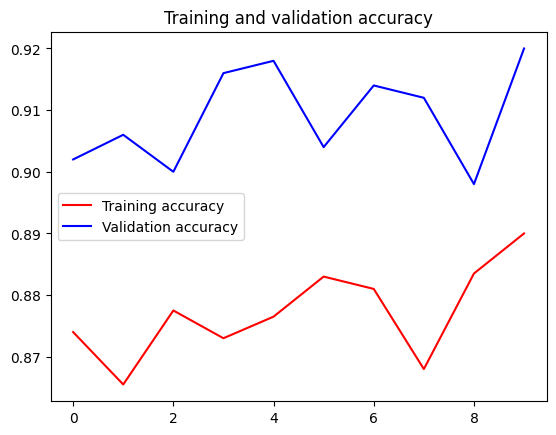

<Figure size 640x480 with 0 Axes>

In [28]:
import matplotlib.pyplot as plt
acc = history_fine.history["accuracy"]
val_acc = history_fine.history["val_accuracy"]
loss = history_fine.history["loss"]
val_loss = history_fine.history["val_loss"]

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()